# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**
*Edición 2023*

----

## **Aprendizaje No Supervisado**
##### *Clustering - Embeddings - Aprendizaje Semi-Supervisado - Reglas de Asociación*

**GRUPO 11**
- Mendoza, Ruben Alfredo
- Risso, Sofia Agostina

__Práctico entregable__


Utilizar la base de jugadores “female_players.csv” disponible en la página de Kaggle https://www.kaggle.com/datasets/stefanoleone992/fifa-23-complete-player-dataset. Consideren que en comparación con la base vista en clase, esta base no tiene los mismos jugadores (ahora mujeres 2023) y no tiene exactamente el mismo formato (a los nombres de las variables se les agregó una keyword para identificar a qué tipo de habilidad corresponde).

Con la nueva base, realizar el siguiente análisis. Notar que es más completo pero análogo al que realizamos con los datos FIFA2019 en el cursado de la materia. Realice comentarios en cada parte (verbose=True ;))


## Carga de datos

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving female_players.csv to female_players (1).csv


In [ ]:
df = pd.read_csv('female_players.csv')
df

<ipython-input-6-201a7086209a>:1: DtypeWarning: Columns (17,20,21,23,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('female_players.csv')


,player_id,player_url,fifa_version,fifa_update,fifa_update_date,short_name,long_name,player_positions,overall,potential,...,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk,player_face_url
0,227125,/player/227125/sam-kerr/230009,23,9,2023-01-13,S. Kerr,Samantha May Kerr,ST,91,91,...,62+3,62+3,64+3,61+3,58+3,58+3,58+3,61+3,20+3,https://cdn.sofifa.net/players/227/125/23_120.png
1,227316,/player/227316/wendie-renard/230009,23,9,2023-01-13,W. Renard,Wéndèleine Thérèse Renard,CB,91,91,...,87+3,87+3,80+3,82+3,91,91,91,82+3,21+3,https://cdn.sofifa.net/players/227/316/23_120.png
2,226301,/player/226301/alex-morgan/230009,23,9,2023-01-13,A. Morgan,Alexandra Morgan Carrasco,ST,90,90,...,67+3,67+3,69+3,66+3,60+3,60+3,60+3,66+3,19+3,https://cdn.sofifa.net/players/226/301/23_120.png
3,227310,/player/227310/ada-hegerberg/230009,23,9,2023-01-13,A. Hegerberg,Ada Martine Stolsmo Hegerberg,ST,90,91,...,61+3,61+3,63+3,60+3,56+3,56+3,56+3,60+3,20+3,https://cdn.sofifa.net/players/227/310/23_120.png
4,227246,/player/227246/lucy-bronze/230009,23,9,2023-01-13,L. Bronze,Lucia Roberta Tough Bronze,RB,89,89,...,86+3,86+3,87+2,87+2,87+2,87+2,87+2,87+2,20+3,https://cdn.sofifa.net/players/227/246/23_120.png
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181356,227385,/player/227385/nkem-ezurike/160001,16,1,2015-08-28,N. Ezurike,Nkem Ezurike,ST,64,71,...,41,41,44,41,37,37,37,41,19,https://cdn.sofifa.net/players/227/385/16_120.png
181357,227485,/player/227485/valeria-miranda/160001,16,1,2015-08-28,V. Miranda,Valeria Aurora Miranda Rodriguez,LB,64,72,...,60,60,62,64,65,65,65,64,17,https://cdn.sofifa.net/players/227/485/16_120.png
181358,228160,/player/228160/linda-tucceri-cimini/160001,16,1,2015-08-28,L. Tucceri Cimini,Linda Tucceri Cimini,"LB, CB",64,71,...,64,64,62,64,68,68,68,64,16,https://cdn.sofifa.net/players/228/160/16_120.png
181359,228723,/player/228723/fabiola-ibarra/160001,16,1,2015-08-28,F. Ibarra,Claudia Fabiola Ibarra Muro,LM,63,68,...,43,43,48,45,36,36,36,45,14,https://cdn.sofifa.net/players/228/723/16_120.png


## __Ejercicio 1__

Análisis exploratorio inicial de la base.

Se pudo observar que el set de datos cuenta con varias entradas para una misma jugadora. Además, cada jugadora posee tres formas diferentes de identificarla: nombre completo, nombre acortado y número de identificación único. Asumiendo que esta información se relaciona de manera biunívoca, se utilizó esta suposición para eliminar filas repetidas para una misma jugadora.

Primero se contó la cantidad de valores unicos tiene cada etiqueta.

In [ ]:
df[['player_id','long_name','short_name']].nunique()

player_id     1635
long_name     1654
short_name    1690
dtype: int64

Se pudo ver que la variable "player_id" que representa el número de identificación, es el que tiene menos valores únicos. Esto quiere decir que hay numeros de id que son compartidos por dos o más jugadoras.

Se contó la cantidad de nombres completos por id y se separaron aquellos que tienen asignados dos o más nombres.

In [ ]:
# Calcular la cantidad de valores únicos de 'long_name' por cada 'player_id'
unique_name_counts = df.groupby('player_id')['long_name'].nunique()
# Filtrar 'player_id' que tienen 2 o más valores únicos en 'long_name'
player_ids_with_multiple_names = unique_name_counts[unique_name_counts >= 2].index.tolist()
# Imprimir los 'player_id' con múltiples nombres distintos
print("player_id con 2 o más nombres distintos:")
for player_id in player_ids_with_multiple_names:
    print(f"Player ID: {player_id}")

player_id con 2 o más nombres distintos:
Player ID: 227314
Player ID: 227404
Player ID: 233834
Player ID: 237197
Player ID: 238257
Player ID: 241844
Player ID: 245189
Player ID: 245198
Player ID: 256213
Player ID: 258576
Player ID: 261838
Player ID: 262330
Player ID: 265908
Player ID: 266451
Player ID: 267673
Player ID: 271054
Player ID: 271945


Al ser pocas filas, se procedió a visualizar los nombres completos para cada id y analizar si hacían referencia a la misma jugadora o eran distintos.

In [ ]:
players_with_multiple_names_df = df[df['player_id'].isin(player_ids_with_multiple_names)][['player_id', 'long_name']]

for id in player_ids_with_multiple_names:
    players_list = players_with_multiple_names_df[players_with_multiple_names_df['player_id'] == id]['long_name'].unique()
    print(f'Para el ID : {id}, se tienen los nombres : {players_list} ')

Para el ID : 227314, se tienen los nombres : ["Jessica Houara-d'Hommeaux" "Jessica Houara-D'Hommeaux"] 
Para el ID : 227404, se tienen los nombres : ['Quinn Quinn' 'Rebecca Quinn'] 
Para el ID : 233834, se tienen los nombres : ['Isabel Kerschowski' 'Isabel Kerschowkski'] 
Para el ID : 237197, se tienen los nombres : ['Onema Grace Geyoro' 'Grace Onema Geyoro'] 
Para el ID : 238257, se tienen los nombres : ['Millie Bright' 'Searson Bright'] 
Para el ID : 241844, se tienen los nombres : ['Sara Björk Gunnarsdóttir' 'Sara Björk Gunnarsdóttir'] 
Para el ID : 245189, se tienen los nombres : ['Diana Natália Facchini Taffarel' 'Daina Natália Facchini Taffarel'
 'Diana Natália Fachini Taffarel'] 
Para el ID : 245198, se tienen los nombres : ['Isia Jade Selva Kenedy' 'Isis Jade Selva Kenedy'] 
Para el ID : 256213, se tienen los nombres : ['Viridiana Salazar' 'Esbeydi Salazar'] 
Para el ID : 258576, se tienen los nombres : ['Teresa José Abelleira Dueñas' 'Teresa Abelleira Dueñas'] 
Para el ID :

Efectivamente se pudo ver que todos los nombres hacían referencia a la misma jugadora, por lo que se procedió a utilizar el número de id para identificar a cada una.

In [ ]:
df[df['player_id'] == 227314]

,player_id,player_url,fifa_version,fifa_update,fifa_update_date,short_name,long_name,player_positions,overall,potential,...,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk,player_face_url
109835,227314,/player/227314/jessica-houara-dhommeaux/180070,18,70,2018-05-22,J. Houara-d'Hommeaux,Jessica Houara-d'Hommeaux,"RB, LB",79,79,...,77+1,77+1,78+1,78+1,76+1,76+1,76+1,78+1,17+1,https://cdn.sofifa.net/players/227/314/18_120.png
110180,227314,/player/227314/jessica-houara-dhommeaux/180069,18,69,2018-05-17,J. Houara-d'Hommeaux,Jessica Houara-d'Hommeaux,"RB, LB",79,79,...,77+1,77+1,78+1,78+1,76+1,76+1,76+1,78+1,17+1,https://cdn.sofifa.net/players/227/314/18_120.png
110527,227314,/player/227314/jessica-houara-dhommeaux/180068,18,68,2018-05-14,J. Houara-d'Hommeaux,Jessica Houara-d'Hommeaux,"RB, LB",79,79,...,77+1,77+1,78+1,78+1,76+1,76+1,76+1,78+1,17+1,https://cdn.sofifa.net/players/227/314/18_120.png
110872,227314,/player/227314/jessica-houara-dhommeaux/180067,18,67,2018-05-10,J. Houara-d'Hommeaux,Jessica Houara-d'Hommeaux,"RB, LB",79,79,...,77+1,77+1,78+1,78+1,76+1,76+1,76+1,78+1,17+1,https://cdn.sofifa.net/players/227/314/18_120.png
111197,227314,/player/227314/jessica-houara-dhommeaux/180066,18,66,2018-05-08,J. Houara-d'Hommeaux,Jessica Houara-d'Hommeaux,"RB, LB",80,80,...,77+1,77+1,79+1,79+1,77+1,77+1,77+1,79+1,17+1,https://cdn.sofifa.net/players/227/314/18_120.png
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180063,227314,/player/227314/jessica-houara-dhommeaux/160005,16,5,2015-10-09,J. Houara-D'Hommeaux,Jessica Houara-D'Hommeaux,"RB, LB",78,78,...,76,76,78,78,75,75,75,78,17,https://cdn.sofifa.net/players/227/314/16_120.png
180338,227314,/player/227314/jessica-houara-dhommeaux/160004,16,4,2015-10-02,J. Houara-D'Hommeaux,Jessica Houara-D'Hommeaux,"RB, LB",78,78,...,76,76,78,78,75,75,75,78,17,https://cdn.sofifa.net/players/227/314/16_120.png
180614,227314,/player/227314/jessica-houara-dhommeaux/160003,16,3,2015-09-25,J. Houara-D'Hommeaux,Jessica Houara-D'Hommeaux,"RB, LB",78,78,...,76,76,78,78,75,75,75,78,17,https://cdn.sofifa.net/players/227/314/16_120.png
180890,227314,/player/227314/jessica-houara-dhommeaux/160002,16,2,2015-09-21,J. Houara-D'Hommeaux,Jessica Houara-D'Hommeaux,"RB, LB",78,78,...,76,76,78,78,75,75,75,78,17,https://cdn.sofifa.net/players/227/314/16_120.png


Como criterio de filtrado de filas repetidas para una misma jugadora, se utilizó la fecha de actualización de datos, quedándonos con aquellas que estuvieran en versiones más recientes.

In [ ]:
df['fifa_update_date'] = pd.to_datetime(df['fifa_update_date'])

In [ ]:
df.sort_values(by=['player_id', 'fifa_update_date'], ascending=[True, False], inplace=True)

In [ ]:
df.drop_duplicates(subset='player_id', keep='first', inplace=True)

In [ ]:
df

,player_id,player_url,fifa_version,fifa_update,fifa_update_date,short_name,long_name,player_positions,overall,potential,...,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk,player_face_url
21,226177,/player/226177/becky-sauerbrunn/230009,23,9,2023-01-13,B. Sauerbrunn,Rebecca Elizabeth Sauerbrunn,CB,86,86,...,79+3,79+3,76+3,78+3,86,86,86,78+3,19+3,https://cdn.sofifa.net/players/226/177/23_120.png
176131,226293,/player/226293/nadine-angerer/160019,16,19,2016-01-07,N. Angerer,Nadine Angerer,GK,86,86,...,24+2,24+2,22+2,21+2,24+2,24+2,24+2,21+2,84+2,https://cdn.sofifa.net/players/226/293/16_120.png
2,226301,/player/226301/alex-morgan/230009,23,9,2023-01-13,A. Morgan,Alexandra Morgan Carrasco,ST,90,90,...,67+3,67+3,69+3,66+3,60+3,60+3,60+3,66+3,19+3,https://cdn.sofifa.net/players/226/301/23_120.png
11,226302,/player/226302/alexandra-popp/230009,23,9,2023-01-13,A. Popp,Alexandra Popp,"ST, LM",87,87,...,69+3,69+3,70+3,68+3,67+3,67+3,67+3,68+3,20+3,https://cdn.sofifa.net/players/226/302/23_120.png
45,226303,/player/226303/almuth-schult/230009,23,9,2023-01-13,A. Schult,Almuth Schult,GK,84,84,...,27+3,27+3,24+3,24+3,27+3,27+3,27+3,24+3,83+1,https://cdn.sofifa.net/players/226/303/23_120.png
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
831,272541,/player/272541/lulu-jarvis/230009,23,9,2023-01-13,L. Jarvis,Lulu Jarvis,CM,57,78,...,54+2,54+2,54+2,54+2,51+2,51+2,51+2,54+2,15+2,https://cdn.sofifa.net/players/272/541/23_120.png
807,272546,/player/272546/reanna-blades/230009,23,9,2023-01-13,R. Blades,Reanna Blades,"RW, RWB",63,84,...,50+2,50+2,52+2,49+2,45+2,45+2,45+2,49+2,15+2,https://cdn.sofifa.net/players/272/546/23_120.png
654,272937,/player/272937/dejana-stefanovic/230009,23,9,2023-01-13,D. Stefanović,Dejana Stefanović,CDM,71,77,...,70+2,70+2,66+2,67+2,72+2,72+2,72+2,67+2,18+2,https://cdn.sofifa.net/players/272/937/23_120.png
702,273010,/player/273010/kathrine-kuhl/230009,23,9,2023-01-13,K. Kühl,Kathrine Kühl,CM,70,90,...,68+2,68+2,62+2,62+2,63+2,63+2,63+2,62+2,15+2,https://cdn.sofifa.net/players/273/010/23_120.png


Además, se decidió mantener solamente a aquellas jugadoras cuyos datos fueron actualizados al 2023.

In [ ]:
df = df[df['fifa_update_date'].dt.year == 2023]
df

,player_id,player_url,fifa_version,fifa_update,fifa_update_date,short_name,long_name,player_positions,overall,potential,...,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk,player_face_url
21,226177,/player/226177/becky-sauerbrunn/230009,23,9,2023-01-13,B. Sauerbrunn,Rebecca Elizabeth Sauerbrunn,CB,86,86,...,79+3,79+3,76+3,78+3,86,86,86,78+3,19+3,https://cdn.sofifa.net/players/226/177/23_120.png
2,226301,/player/226301/alex-morgan/230009,23,9,2023-01-13,A. Morgan,Alexandra Morgan Carrasco,ST,90,90,...,67+3,67+3,69+3,66+3,60+3,60+3,60+3,66+3,19+3,https://cdn.sofifa.net/players/226/301/23_120.png
11,226302,/player/226302/alexandra-popp/230009,23,9,2023-01-13,A. Popp,Alexandra Popp,"ST, LM",87,87,...,69+3,69+3,70+3,68+3,67+3,67+3,67+3,68+3,20+3,https://cdn.sofifa.net/players/226/302/23_120.png
45,226303,/player/226303/almuth-schult/230009,23,9,2023-01-13,A. Schult,Almuth Schult,GK,84,84,...,27+3,27+3,24+3,24+3,27+3,27+3,27+3,24+3,83+1,https://cdn.sofifa.net/players/226/303/23_120.png
46,226308,/player/226308/dzsenifer-marozsan/230009,23,9,2023-01-13,D. Marozsán,Dzsenifer Marozsán,"CAM, CM",84,84,...,72+3,72+3,73+3,69+3,65+3,65+3,65+3,69+3,18+3,https://cdn.sofifa.net/players/226/308/23_120.png
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
831,272541,/player/272541/lulu-jarvis/230009,23,9,2023-01-13,L. Jarvis,Lulu Jarvis,CM,57,78,...,54+2,54+2,54+2,54+2,51+2,51+2,51+2,54+2,15+2,https://cdn.sofifa.net/players/272/541/23_120.png
807,272546,/player/272546/reanna-blades/230009,23,9,2023-01-13,R. Blades,Reanna Blades,"RW, RWB",63,84,...,50+2,50+2,52+2,49+2,45+2,45+2,45+2,49+2,15+2,https://cdn.sofifa.net/players/272/546/23_120.png
654,272937,/player/272937/dejana-stefanovic/230009,23,9,2023-01-13,D. Stefanović,Dejana Stefanović,CDM,71,77,...,70+2,70+2,66+2,67+2,72+2,72+2,72+2,67+2,18+2,https://cdn.sofifa.net/players/272/937/23_120.png
702,273010,/player/273010/kathrine-kuhl/230009,23,9,2023-01-13,K. Kühl,Kathrine Kühl,CM,70,90,...,68+2,68+2,62+2,62+2,63+2,63+2,63+2,62+2,15+2,https://cdn.sofifa.net/players/273/010/23_120.png


In [ ]:
df['player_id'].nunique()

832

In [ ]:
df['long_name'].nunique()

832

Dado que solo nos interesaba evaluar las habilidades de las jugadoras, se separaron aquellas columnas que dieran información sobre estas características.

In [ ]:
np.array(df.columns.tolist()).flatten()

array(['player_id', 'player_url', 'fifa_version', 'fifa_update',
       'fifa_update_date', 'short_name', 'long_name', 'player_positions',
       'overall', 'potential', 'value_eur', 'wage_eur', 'age', 'dob',
       'height_cm', 'weight_kg', 'league_id', 'league_name',
       'league_level', 'club_team_id', 'club_name', 'club_position',
       'club_jersey_number', 'club_loaned_from', 'club_joined_date',
       'club_contract_valid_until_year', 'nationality_id',
       'nationality_name', 'nation_team_id', 'nation_position',
       'nation_jersey_number', 'preferred_foot', 'weak_foot',
       'skill_moves', 'international_reputation', 'work_rate',
       'body_type', 'real_face', 'release_clause_eur', 'player_tags',
       'player_traits', 'pace', 'shooting', 'passing', 'dribbling',
       'defending', 'physic', 'attacking_crossing', 'attacking_finishing',
       'attacking_heading_accuracy', 'attacking_short_passing',
       'attacking_volleys', 'skill_dribbling', 'skill_curve',
     

In [ ]:
interest_columns = ['long_name', 'player_positions', 'overall', 'potential', 'height_cm',
                    'weight_kg', 'preferred_foot', 'weak_foot', 'skill_moves', 'work_rate',
                    'player_tags', 'player_traits', 'pace', 'shooting', 'passing',
                    'dribbling', 'defending', 'physic', 'attacking_crossing',
                    'attacking_finishing', 'attacking_heading_accuracy',
                    'attacking_short_passing', 'attacking_volleys', 'skill_dribbling',
                    'skill_curve', 'skill_fk_accuracy', 'skill_long_passing',
                    'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed',
                    'movement_agility', 'movement_reactions', 'movement_balance',
                    'power_shot_power', 'power_jumping', 'power_stamina',
                    'power_strength', 'power_long_shots', 'mentality_aggression',
                    'mentality_interceptions', 'mentality_positioning', 'mentality_vision',
                    'mentality_penalties', 'mentality_composure', 'defending_marking_awareness',
                    'defending_standing_tackle', 'defending_sliding_tackle',
                    'goalkeeping_diving', 'goalkeeping_handling', 'goalkeeping_kicking',
                    'goalkeeping_positioning', 'goalkeeping_reflexes', 'goalkeeping_speed',
                    'ls', 'st', 'rs', 'lw', 'lf', 'cf', 'rf', 'rw', 'lam', 'cam',
                    'ram', 'lm', 'lcm', 'cm', 'rcm', 'rm', 'lwb', 'ldm', 'cdm',
                    'rdm', 'rwb', 'lb', 'lcb', 'cb', 'rcb', 'rb', 'gk'
                    ]

Se crearon dos set de datos nuevos: el primero de ellos tiene sólo valores numéricos que se usarán posteriormente con algoritmos de Aprendizaje No Supervisado; mientras que el segundo tiene algunas variables categóricas para ser analizadas cualitativamente.

In [ ]:
df_clean = df[interest_columns]

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 832 entries, 21 to 754
Data columns (total 80 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   long_name                    832 non-null    object 
 1   player_positions             832 non-null    object 
 2   overall                      832 non-null    int64  
 3   potential                    832 non-null    int64  
 4   height_cm                    832 non-null    int64  
 5   weight_kg                    832 non-null    int64  
 6   preferred_foot               832 non-null    object 
 7   weak_foot                    832 non-null    int64  
 8   skill_moves                  832 non-null    int64  
 9   work_rate                    832 non-null    object 
 10  player_tags                  104 non-null    object 
 11  player_traits                358 non-null    object 
 12  pace                         732 non-null    float64
 13  shooting           

Dado que se necesitaba obtener un set de datos solo con valores numéricos, se separaron las columnas categóricas para poder hacer la codificación.

In [ ]:
df_object = df_clean.select_dtypes(include=['object'])
df_object

,long_name,player_positions,preferred_foot,work_rate,player_tags,player_traits,ls,st,rs,lw,...,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk
21,Rebecca Elizabeth Sauerbrunn,CB,Right,Medium/High,"#Tackling, #Strength","Leadership, Team Player",61+3,61+3,61+3,62,...,79+3,79+3,79+3,76+3,78+3,86,86,86,78+3,19+3
2,Alexandra Morgan Carrasco,ST,Left,High/Low,#Clinical Finisher,"Leadership, Finesse Shot, Flair, Speed Dribble...",90,90,90,87,...,67+3,67+3,67+3,69+3,66+3,60+3,60+3,60+3,66+3,19+3
11,Alexandra Popp,"ST, LM",Left,High/High,"#Aerial Threat, #Distance Shooter, #Clinical F...","Injury Prone, Leadership, Power Header, Outsid...",87,87,87,83,...,69+3,69+3,69+3,70+3,68+3,67+3,67+3,67+3,68+3,20+3
45,Almuth Schult,GK,Right,Medium/Medium,NaN,Saves with Feet,29+3,29+3,29+3,24,...,27+3,27+3,27+3,24+3,24+3,27+3,27+3,27+3,24+3,83+1
46,Dzsenifer Marozsán,"CAM, CM",Right,High/Low,"#Dribbler, #Crosser, #FK Specialist","Injury Prone, Long Shot Taker (AI), Playmaker ...",80+3,80+3,80+3,84,...,72+3,72+3,72+3,73+3,69+3,65+3,65+3,65+3,69+3,18+3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
831,Lulu Jarvis,CM,Right,Medium/Medium,NaN,NaN,53+2,53+2,53+2,57,...,54+2,54+2,54+2,54+2,54+2,51+2,51+2,51+2,54+2,15+2
807,Reanna Blades,"RW, RWB",Right,Medium/Medium,NaN,Speed Dribbler (AI),57+2,57+2,57+2,63,...,50+2,50+2,50+2,52+2,49+2,45+2,45+2,45+2,49+2,15+2
654,Dejana Stefanović,CDM,Right,Medium/Medium,NaN,Playmaker (AI),59+2,59+2,59+2,61,...,70+2,70+2,70+2,66+2,67+2,72+2,72+2,72+2,67+2,18+2
702,Kathrine Kühl,CM,Right,Medium/Medium,NaN,Flair,62+2,62+2,62+2,65,...,68+2,68+2,68+2,62+2,62+2,63+2,63+2,63+2,62+2,15+2


In [ ]:
df_object.columns

Index(['long_name', 'player_positions', 'preferred_foot', 'work_rate',
       'player_tags', 'player_traits', 'ls', 'st', 'rs', 'lw', 'lf', 'cf',
       'rf', 'rw', 'lam', 'cam', 'ram', 'lm', 'lcm', 'cm', 'rcm', 'rm', 'lwb',
       'ldm', 'cdm', 'rdm', 'rwb', 'lb', 'lcb', 'cb', 'rcb', 'rb', 'gk'],
      dtype='object')

Se separaron las columnas que representaban la puntuación de cada jugadora en una determinada posición.

In [ ]:
position_score_columns = ['ls', 'st', 'rs', 'lw', 'lf', 'cf', 'rf', 'rw', 'lam', 'cam', 'ram',
           'lm', 'lcm', 'cm', 'rcm', 'rm', 'lwb', 'ldm', 'cdm', 'rdm', 'rwb',
           'lb', 'lcb', 'cb','rcb', 'rb', 'gk']

In [ ]:
df_object[position_score_columns]

,ls,st,rs,lw,lf,cf,rf,rw,lam,cam,...,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk
21,61+3,61+3,61+3,62,62,62,62,62,64+3,64+3,...,79+3,79+3,79+3,76+3,78+3,86,86,86,78+3,19+3
2,90,90,90,87,89,89,89,87,87+3,87+3,...,67+3,67+3,67+3,69+3,66+3,60+3,60+3,60+3,66+3,19+3
11,87,87,87,83,85,85,85,83,83+3,83+3,...,69+3,69+3,69+3,70+3,68+3,67+3,67+3,67+3,68+3,20+3
45,29+3,29+3,29+3,24,27,27,27,24,26+3,26+3,...,27+3,27+3,27+3,24+3,24+3,27+3,27+3,27+3,24+3,83+1
46,80+3,80+3,80+3,84,83,83,83,84,84,84,...,72+3,72+3,72+3,73+3,69+3,65+3,65+3,65+3,69+3,18+3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
831,53+2,53+2,53+2,57,56,56,56,57,58+2,58+2,...,54+2,54+2,54+2,54+2,54+2,51+2,51+2,51+2,54+2,15+2
807,57+2,57+2,57+2,63,61,61,61,63,62+2,62+2,...,50+2,50+2,50+2,52+2,49+2,45+2,45+2,45+2,49+2,15+2
654,59+2,59+2,59+2,61,61,61,61,61,64+2,64+2,...,70+2,70+2,70+2,66+2,67+2,72+2,72+2,72+2,67+2,18+2
702,62+2,62+2,62+2,65,67,67,67,65,70+2,70+2,...,68+2,68+2,68+2,62+2,62+2,63+2,63+2,63+2,62+2,15+2


Posteriormente, se procedó a convertir dichos valores a números.

In [ ]:
def convert_to_numeric(value):
    if '+' in value:
        parts = value.split('+')
        return int(parts[0]) + int(parts[1])
    elif '-' in value:
        parts = value.split('-')
        return int(parts[0]) - int(parts[1])
    else:
        return int(value)

In [ ]:
for column in position_score_columns:
    df_clean[column] = df_clean[column].apply(convert_to_numeric)

<ipython-input-27-a02b1a1e0ffd>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[column] = df_clean[column].apply(convert_to_numeric)


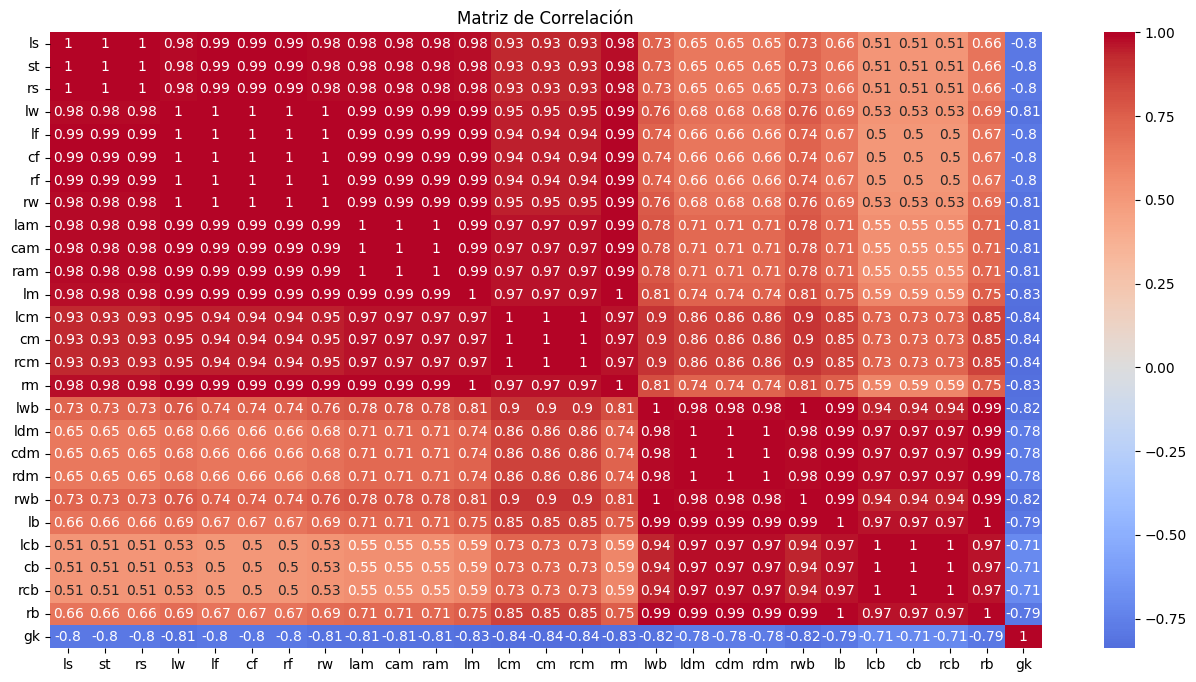

In [ ]:
# Calcular la matriz de correlación
correlation_matrix = df_clean[position_score_columns].corr()

# Crear un gráfico de correlación utilizando seaborn
plt.figure(figsize=(16, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')
plt.show()

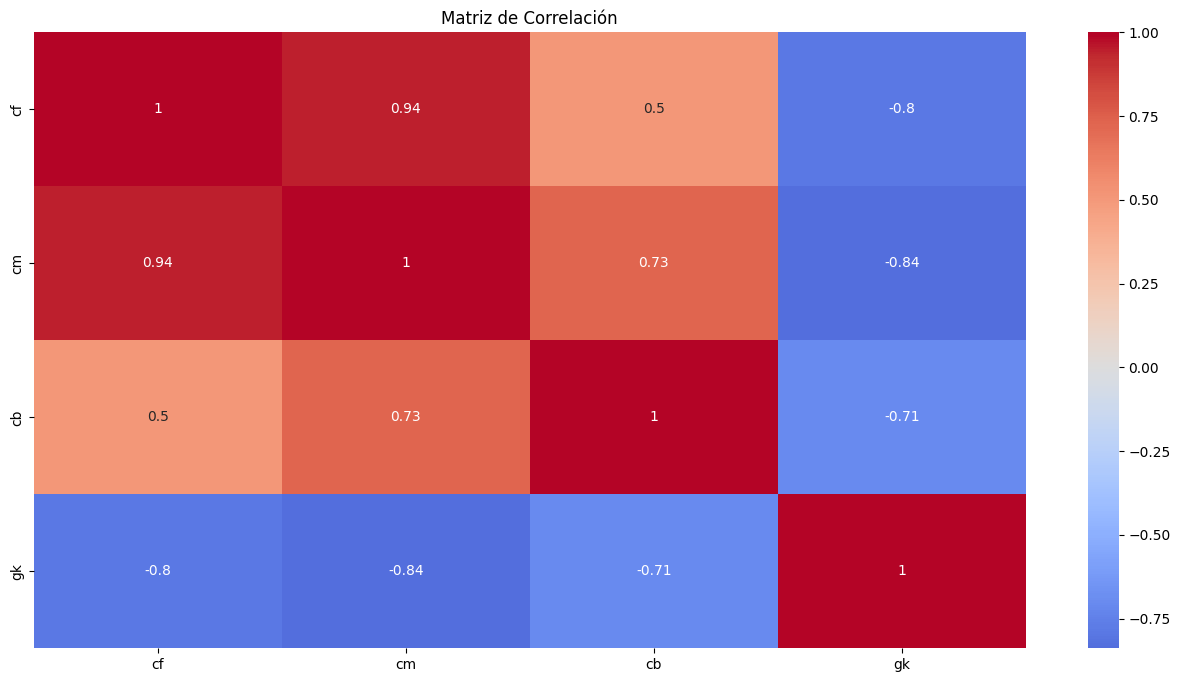

In [ ]:
df_clean = df_clean.drop(['ls','st','rs','lw','lf','rf','rw','lam','cam',
                        'ram','lm','lcm','rcm','rm','ldm','cdm','rdm',
                        'lb','lwb','lcb','rcb','rwb','rb'], axis = 1)

corr_reduc_columns = ['cf','cm','cb','gk']

# Calcular la matriz de correlación
correlation_matrix = df_clean[corr_reduc_columns].corr()

# Crear un gráfico de correlación utilizando seaborn
plt.figure(figsize=(16, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')
plt.show()

La columna _"work_rate"_ representa el grado de esfuerzo que realiza la jugadora en cuanto a ataque y defensa, valorado como bajo, medio y alto. Esta función se divide en dos funciones nuevas: _AttackWorkRate_ y _DefenseWorkRate_.

Para su codificación se utilizó:
 - 0 para Low (bajo)
 - 0,5 para Medium (medio)
 - 1 para High (alto)

In [ ]:
df_object['work_rate'].unique()

array(['Medium/High', 'High/Low', 'High/High', 'Medium/Medium',
       'High/Medium', 'Low/High', 'Medium/Low', 'Low/Medium'],
      dtype=object)

Luego se separaron en dos columnas las características referentes al ataque y a la defensa para posteriormente codificarlas. Es importante aclarar que sólo se codificó el set de datos que que contenía valores numéricos únicamente.

In [ ]:
df_clean[['AttackWorkRate', 'DefenseWorkRate']] = df_clean['work_rate'].str.split('/', expand=True)

encoding_map = {
    'Low': 0,
    'Medium': 0.5,
    'High': 1
}

# Aplicar la codificación a las columnas
df_clean['AttackWorkRate'] = df_clean['AttackWorkRate'].replace(encoding_map)
df_clean['DefenseWorkRate'] = df_clean['DefenseWorkRate'].replace(encoding_map)

df_clean  = df_clean.drop(['work_rate'], axis = 1)

In [ ]:
df_object = df_clean.select_dtypes(include=['object'])
df_object

,long_name,player_positions,preferred_foot,player_tags,player_traits
21,Rebecca Elizabeth Sauerbrunn,CB,Right,"#Tackling, #Strength","Leadership, Team Player"
2,Alexandra Morgan Carrasco,ST,Left,#Clinical Finisher,"Leadership, Finesse Shot, Flair, Speed Dribble..."
11,Alexandra Popp,"ST, LM",Left,"#Aerial Threat, #Distance Shooter, #Clinical F...","Injury Prone, Leadership, Power Header, Outsid..."
45,Almuth Schult,GK,Right,NaN,Saves with Feet
46,Dzsenifer Marozsán,"CAM, CM",Right,"#Dribbler, #Crosser, #FK Specialist","Injury Prone, Long Shot Taker (AI), Playmaker ..."
...,...,...,...,...,...
831,Lulu Jarvis,CM,Right,NaN,NaN
807,Reanna Blades,"RW, RWB",Right,NaN,Speed Dribbler (AI)
654,Dejana Stefanović,CDM,Right,NaN,Playmaker (AI)
702,Kathrine Kühl,CM,Right,NaN,Flair


En la columna _"player_positions"_ se encuentra la posición en la que juega cada jugadora.

In [ ]:
df_object['player_positions'].unique()

array(['CB', 'ST', 'ST, LM', 'GK', 'CAM, CM', 'LB, RB', 'ST, LW',
       'LW, LM', 'CAM, LB', 'CM, CAM', 'CAM, LM', 'CM, CDM',
       'CAM, ST, LW', 'ST, CAM', 'CB, RB', 'CM, CAM, CDM', 'ST, CB',
       'CB, LB', 'CB, RB, LB', 'RB, RM', 'LM, ST', 'ST, RM, LM', 'RM, LM',
       'LW, LWB', 'CAM, CM, ST', 'CDM, CM, RB', 'CB, CM', 'LW, ST',
       'LW, RW, LB', 'LM, RM', 'CB, CDM', 'CAM, ST', 'LB, LM', 'RW, CAM',
       'CM', 'RB', 'CAM, RW, RM', 'CDM, CM', 'CM, LW', 'LB', 'RB, CB',
       'RB, RWB, LB', 'LM, CAM, ST', 'CAM, ST, CM', 'RM, ST, LM',
       'RM, ST, CAM', 'LW, CM', 'RB, LB', 'RW, ST', 'LB, CB',
       'CM, RW, LW', 'ST, LW, RW', 'CDM, CB', 'CDM', 'CAM, CM, RM',
       'LM, CM', 'CM, CDM, CAM', 'RWB, RB, CM', 'LW, CF', 'CAM, RM', 'RW',
       'CM, CDM, RB', 'LB, RB, RWB', 'CB, RB, CDM', 'ST, CAM, LB',
       'RB, CB, LB', 'CB, CDM, RM', 'CAM, LM, CF', 'RB, RWB, CB',
       'CAM, CM, RW', 'RW, ST, RB', 'RW, CM', 'RM', 'RM, LW, CAM',
       'LW, RW', 'CAM, LW', 'LM', 'RB, LB, CB

In [ ]:
forwards = ['RF', 'ST', 'CF', 'LW', 'LF', 'RS', 'LS', 'RW']
midfielders = ['RCM', 'LCM', 'LDM', 'CDM', 'RDM', 'CM', 'RM', 'LM', 'CAM', 'LAM', 'RAM']
defenders = ['RCB', 'CB', 'LCB', 'LB', 'RB', 'RWB', 'LWB']
goalkeepers = ['GK']

def position_codifi(position):
    positions = position.split(', ')
    first_position = positions[0] if positions else 'nan'

    if first_position in forwards:
        return 'Forward'

    elif first_position in midfielders:
        return 'Midfielder'

    elif first_position in defenders:
        return 'Defender'

    elif first_position in goalkeepers:
        return 'Goalkeeper'

    else:
        return 'nan'


Fue posible observar que hay jugadoras que juegan en más de una posición. Antes de codificarlas, se guardaron estas posiciones en una lista para posteriormente realizar un análisis cualitativo.

In [ ]:
df_clean['player_positions'] = df_clean['player_positions'].apply(position_codifi)

Se realizó un OneHotEncoding para transformar las variables categóricas a numéricas.

In [ ]:
encoded_positions = pd.get_dummies(df_clean['player_positions'].apply(pd.Series).stack(), prefix = 'position').sum(level=0)
encoded_positions

<ipython-input-36-e97e95c964d1>:1: FutureWarning: Using the level keyword in DataFrame and Series aggregations is deprecated and will be removed in a future version. Use groupby instead. df.sum(level=1) should use df.groupby(level=1).sum().
  encoded_positions = pd.get_dummies(df_clean['player_positions'].apply(pd.Series).stack(), prefix = 'position').sum(level=0)


,position_Defender,position_Forward,position_Goalkeeper,position_Midfielder
21,1,0,0,0
2,0,1,0,0
11,0,1,0,0
45,0,0,1,0
46,0,0,0,1
...,...,...,...,...
831,0,0,0,1
807,0,1,0,0
654,0,0,0,1
702,0,0,0,1


Se concatenó este dataframe codificado con el dataframe que se venía armando.

In [ ]:
df_clean = pd.concat([df_clean, encoded_positions], axis=1)
df_clean

,long_name,player_positions,overall,potential,height_cm,weight_kg,preferred_foot,weak_foot,skill_moves,player_tags,...,cf,cm,cb,gk,AttackWorkRate,DefenseWorkRate,position_Defender,position_Forward,position_Goalkeeper,position_Midfielder
21,Rebecca Elizabeth Sauerbrunn,Defender,86,86,170,64,Right,3,3,"#Tackling, #Strength",...,62,71,86,22,0.5,1.0,1,0,0,0
2,Alexandra Morgan Carrasco,Forward,90,90,168,62,Left,4,4,#Clinical Finisher,...,89,85,63,22,1.0,0.0,0,1,0,0
11,Alexandra Popp,Forward,87,87,174,65,Left,5,3,"#Aerial Threat, #Distance Shooter, #Clinical F...",...,85,81,70,23,1.0,1.0,0,1,0,0
45,Almuth Schult,Goalkeeper,84,84,180,71,Right,2,1,NaN,...,27,29,30,84,0.5,0.5,0,0,1,0
46,Dzsenifer Marozsán,Midfielder,84,84,171,67,Right,4,5,"#Dribbler, #Crosser, #FK Specialist",...,83,84,68,21,1.0,0.0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
831,Lulu Jarvis,Midfielder,57,78,165,57,Right,3,2,NaN,...,56,59,53,17,0.5,0.5,0,0,0,1
807,Reanna Blades,Forward,63,84,165,58,Right,3,3,NaN,...,61,59,47,17,0.5,0.5,0,1,0,0
654,Dejana Stefanović,Midfielder,71,77,171,66,Right,5,3,NaN,...,61,69,74,20,0.5,0.5,0,0,0,1
702,Kathrine Kühl,Midfielder,70,90,172,60,Right,3,3,NaN,...,67,72,65,17,0.5,0.5,0,0,0,1


Se codificó y concatenó además, el dataframe con los valores de la pierna hábil de la jugadora.

In [ ]:
encoded_preferred_foot = pd.get_dummies(df_clean['preferred_foot'], prefix = 'preferred_foot')
encoded_preferred_foot

,preferred_foot_Left,preferred_foot_Right
21,0,1
2,1,0
11,1,0
45,0,1
46,0,1
...,...,...
831,0,1
807,0,1
654,0,1
702,0,1


In [ ]:
df_clean = pd.concat([df_clean, encoded_preferred_foot], axis=1)
df_clean

,long_name,player_positions,overall,potential,height_cm,weight_kg,preferred_foot,weak_foot,skill_moves,player_tags,...,cb,gk,AttackWorkRate,DefenseWorkRate,position_Defender,position_Forward,position_Goalkeeper,position_Midfielder,preferred_foot_Left,preferred_foot_Right
21,Rebecca Elizabeth Sauerbrunn,Defender,86,86,170,64,Right,3,3,"#Tackling, #Strength",...,86,22,0.5,1.0,1,0,0,0,0,1
2,Alexandra Morgan Carrasco,Forward,90,90,168,62,Left,4,4,#Clinical Finisher,...,63,22,1.0,0.0,0,1,0,0,1,0
11,Alexandra Popp,Forward,87,87,174,65,Left,5,3,"#Aerial Threat, #Distance Shooter, #Clinical F...",...,70,23,1.0,1.0,0,1,0,0,1,0
45,Almuth Schult,Goalkeeper,84,84,180,71,Right,2,1,NaN,...,30,84,0.5,0.5,0,0,1,0,0,1
46,Dzsenifer Marozsán,Midfielder,84,84,171,67,Right,4,5,"#Dribbler, #Crosser, #FK Specialist",...,68,21,1.0,0.0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
831,Lulu Jarvis,Midfielder,57,78,165,57,Right,3,2,NaN,...,53,17,0.5,0.5,0,0,0,1,0,1
807,Reanna Blades,Forward,63,84,165,58,Right,3,3,NaN,...,47,17,0.5,0.5,0,1,0,0,0,1
654,Dejana Stefanović,Midfielder,71,77,171,66,Right,5,3,NaN,...,74,20,0.5,0.5,0,0,0,1,0,1
702,Kathrine Kühl,Midfielder,70,90,172,60,Right,3,3,NaN,...,65,17,0.5,0.5,0,0,0,1,0,1


In [ ]:
df_object = df_clean.select_dtypes(include=['object'])
df_object

,long_name,player_positions,preferred_foot,player_tags,player_traits
21,Rebecca Elizabeth Sauerbrunn,Defender,Right,"#Tackling, #Strength","Leadership, Team Player"
2,Alexandra Morgan Carrasco,Forward,Left,#Clinical Finisher,"Leadership, Finesse Shot, Flair, Speed Dribble..."
11,Alexandra Popp,Forward,Left,"#Aerial Threat, #Distance Shooter, #Clinical F...","Injury Prone, Leadership, Power Header, Outsid..."
45,Almuth Schult,Goalkeeper,Right,NaN,Saves with Feet
46,Dzsenifer Marozsán,Midfielder,Right,"#Dribbler, #Crosser, #FK Specialist","Injury Prone, Long Shot Taker (AI), Playmaker ..."
...,...,...,...,...,...
831,Lulu Jarvis,Midfielder,Right,NaN,NaN
807,Reanna Blades,Forward,Right,NaN,Speed Dribbler (AI)
654,Dejana Stefanović,Midfielder,Right,NaN,Playmaker (AI)
702,Kathrine Kühl,Midfielder,Right,NaN,Flair


En la columna _"player_tags"_ se encuentran las etiquetas que identifican las habilidades de la jugadora, por ejemplo: Regateadora, Tiradora a distancia, Cruzadora, Velocista, etc.

Al igual que se hizo con la columna _"player_positions"_, se guardaron estas etiquetas en una lista para cada jugadora.

In [ ]:
def process_tags(tags):
    if isinstance(tags, str):
        unique_tags = set()
        for tag in tags.split(','):
            cleaned_tag = tag.strip('# ')
            # Eliminar espacios adicionales dentro de la etiqueta
            cleaned_tag = ' '.join(cleaned_tag.split())
            unique_tags.add(cleaned_tag)
        return list(unique_tags)
    else:
        return []


In [ ]:
df_clean['player_tags'] = df_clean['player_tags'].apply(process_tags)

Se realizó el mismo procedimiento para la columna _"player_traits"_ que representan los rasgos de una jugadora, es decir, acciones que es más probable que realice en los partidos.



In [ ]:
def process_traits(traits):
    if isinstance(traits, str):
        return [trait.strip() for trait in traits.split(',')]
    else:
        return []

In [ ]:
df_clean['player_traits'] = df_clean['player_traits'].apply(process_traits)

Luego de tener los valores separados, se procedió a realizar las codificaciones y concatenaciones correspondientes.

In [ ]:
encoded_tags = pd.get_dummies(df_clean['player_tags'].apply(pd.Series).stack(), prefix = 'tag').sum(level=0)
encoded_tags

<ipython-input-45-ec82c533b224>:1: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  encoded_tags = pd.get_dummies(df_clean['player_tags'].apply(pd.Series).stack(), prefix = 'tag').sum(level=0)
<ipython-input-45-ec82c533b224>:1: FutureWarning: Using the level keyword in DataFrame and Series aggregations is deprecated and will be removed in a future version. Use groupby instead. df.sum(level=1) should use df.groupby(level=1).sum().
  encoded_tags = pd.get_dummies(df_clean['player_tags'].apply(pd.Series).stack(), prefix = 'tag').sum(level=0)


,tag_Acrobat,tag_Aerial Threat,tag_Clinical Finisher,tag_Complete Defender,tag_Complete Forward,tag_Complete Midfielder,tag_Crosser,tag_Distance Shooter,tag_Dribbler,tag_Engine,tag_FK Specialist,tag_Playmaker,tag_Poacher,tag_Speedster,tag_Strength,tag_Tackling,tag_Tactician
21,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0
2,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
11,0,1,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0
46,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0
22,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
285,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
173,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
286,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
552,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


In [ ]:
df_clean = pd.concat([df_clean, encoded_tags], axis=1)
df_clean

,long_name,player_positions,overall,potential,height_cm,weight_kg,preferred_foot,weak_foot,skill_moves,player_tags,...,tag_Distance Shooter,tag_Dribbler,tag_Engine,tag_FK Specialist,tag_Playmaker,tag_Poacher,tag_Speedster,tag_Strength,tag_Tackling,tag_Tactician
21,Rebecca Elizabeth Sauerbrunn,Defender,86,86,170,64,Right,3,3,"[Tackling, Strength]",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,Alexandra Morgan Carrasco,Forward,90,90,168,62,Left,4,4,[Clinical Finisher],...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11,Alexandra Popp,Forward,87,87,174,65,Left,5,3,"[Distance Shooter, Aerial Threat, Clinical Fin...",...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
45,Almuth Schult,Goalkeeper,84,84,180,71,Right,2,1,[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,Dzsenifer Marozsán,Midfielder,84,84,171,67,Right,4,5,"[FK Specialist, Crosser, Dribbler]",...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
831,Lulu Jarvis,Midfielder,57,78,165,57,Right,3,2,[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
807,Reanna Blades,Forward,63,84,165,58,Right,3,3,[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
654,Dejana Stefanović,Midfielder,71,77,171,66,Right,5,3,[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
702,Kathrine Kühl,Midfielder,70,90,172,60,Right,3,3,[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
encoded_traits = pd.get_dummies(df_clean['player_traits'].apply(pd.Series).stack(), prefix = 'traits').sum(level=0)
encoded_traits

<ipython-input-47-d41491101c16>:1: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  encoded_traits = pd.get_dummies(df_clean['player_traits'].apply(pd.Series).stack(), prefix = 'traits').sum(level=0)
<ipython-input-47-d41491101c16>:1: FutureWarning: Using the level keyword in DataFrame and Series aggregations is deprecated and will be removed in a future version. Use groupby instead. df.sum(level=1) should use df.groupby(level=1).sum().
  encoded_traits = pd.get_dummies(df_clean['player_traits'].apply(pd.Series).stack(), prefix = 'traits').sum(level=0)


,traits_Cautious With Crosses,traits_Chip Shot (AI),traits_Comes For Crosses,traits_Dives Into Tackles (AI),traits_Early Crosser,traits_Finesse Shot,traits_Flair,traits_GK Long Throw,traits_Giant Throw-in,traits_Injury Prone,...,traits_Outside Foot Shot,traits_Playmaker (AI),traits_Power Free-Kick,traits_Power Header,traits_Rushes Out Of Goal,traits_Saves with Feet,traits_Solid Player,traits_Speed Dribbler (AI),traits_Team Player,traits_Technical Dribbler (AI)
21,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,1,1,0,0,0,...,1,0,0,0,0,0,0,1,1,0
11,0,0,0,0,0,0,0,0,0,1,...,1,0,0,1,0,0,0,0,1,0
45,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
46,0,0,0,0,0,0,0,0,0,1,...,1,1,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
442,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
701,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
807,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
654,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [ ]:
df_clean = pd.concat([df_clean, encoded_traits], axis=1)
df_clean

,long_name,player_positions,overall,potential,height_cm,weight_kg,preferred_foot,weak_foot,skill_moves,player_tags,...,traits_Outside Foot Shot,traits_Playmaker (AI),traits_Power Free-Kick,traits_Power Header,traits_Rushes Out Of Goal,traits_Saves with Feet,traits_Solid Player,traits_Speed Dribbler (AI),traits_Team Player,traits_Technical Dribbler (AI)
21,Rebecca Elizabeth Sauerbrunn,Defender,86,86,170,64,Right,3,3,"[Tackling, Strength]",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,Alexandra Morgan Carrasco,Forward,90,90,168,62,Left,4,4,[Clinical Finisher],...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
11,Alexandra Popp,Forward,87,87,174,65,Left,5,3,"[Distance Shooter, Aerial Threat, Clinical Fin...",...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
45,Almuth Schult,Goalkeeper,84,84,180,71,Right,2,1,[],...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
46,Dzsenifer Marozsán,Midfielder,84,84,171,67,Right,4,5,"[FK Specialist, Crosser, Dribbler]",...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
831,Lulu Jarvis,Midfielder,57,78,165,57,Right,3,2,[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
807,Reanna Blades,Forward,63,84,165,58,Right,3,3,[],...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
654,Dejana Stefanović,Midfielder,71,77,171,66,Right,5,3,[],...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
702,Kathrine Kühl,Midfielder,70,90,172,60,Right,3,3,[],...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Se eliminaron las columnas categóricas ya codificadas.

In [ ]:
df_clean = df_clean.drop(['player_positions', 'preferred_foot', 'player_tags', 'player_traits'], axis = 1).reset_index(drop=True)
df_clean

,long_name,overall,potential,height_cm,weight_kg,weak_foot,skill_moves,pace,shooting,passing,...,traits_Outside Foot Shot,traits_Playmaker (AI),traits_Power Free-Kick,traits_Power Header,traits_Rushes Out Of Goal,traits_Saves with Feet,traits_Solid Player,traits_Speed Dribbler (AI),traits_Team Player,traits_Technical Dribbler (AI)
0,Rebecca Elizabeth Sauerbrunn,86,86,170,64,3,3,68.0,44.0,61.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,Alexandra Morgan Carrasco,90,90,168,62,4,4,89.0,91.0,80.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,Alexandra Popp,87,87,174,65,5,3,79.0,88.0,76.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,Almuth Schult,84,84,180,71,2,1,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,Dzsenifer Marozsán,84,84,171,67,4,5,77.0,82.0,87.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
827,Lulu Jarvis,57,78,165,57,3,2,69.0,48.0,55.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
828,Reanna Blades,63,84,165,58,3,3,83.0,52.0,57.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
829,Dejana Stefanović,71,77,171,66,5,3,65.0,48.0,65.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
830,Kathrine Kühl,70,90,172,60,3,3,69.0,54.0,64.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


A partir de aquí, teniendo el set de datos ya codificado, se comenzó con el proceso de imputación de valores faltantes.

Se inició contando la cantidad de valores faltantes por columna para analizar la forma correcta de imputación.

In [ ]:
val_falt = df_clean.isnull().sum()
val_falt[val_falt > 0]

pace                              100
shooting                          100
passing                           100
dribbling                         100
defending                         100
physic                            100
goalkeeping_speed                 732
tag_Acrobat                       728
tag_Aerial Threat                 728
tag_Clinical Finisher             728
tag_Complete Defender             728
tag_Complete Forward              728
tag_Complete Midfielder           728
tag_Crosser                       728
tag_Distance Shooter              728
tag_Dribbler                      728
tag_Engine                        728
tag_FK Specialist                 728
tag_Playmaker                     728
tag_Poacher                       728
tag_Speedster                     728
tag_Strength                      728
tag_Tackling                      728
tag_Tactician                     728
traits_Cautious With Crosses      474
traits_Chip Shot (AI)             474
traits_Comes

Es importante mencionar que todas las columnas que tienen prefijos "tags" o "traits" en sus nombres que tienen valores faltantes,  son aquellas que no presentaban atributos o rasgos en el set de datos original. Teniendo en cuenta el criterio de codificación OneHotEncoding, si una jugadora tiene un atributo o rasgo, tendra el valor 1 en la columna correspondiente a dicho atributo y un 0 si no lo presenta. Por lo tanto, aquellas jugadoras que no presenten ningún atributo o rasgo, tedrán 0 en todas las columnas. Esto constituye un criterio para imputar los valores faltantes en todas estas columnas.

In [ ]:
columns_to_fill_with_zero = ['tag_Acrobat',
                            'tag_Aerial Threat', 'tag_Clinical Finisher',
                            'tag_Complete Defender', 'tag_Complete Forward',
                            'tag_Complete Midfielder', 'tag_Crosser', 'tag_Distance Shooter',
                            'tag_Dribbler', 'tag_Engine', 'tag_FK Specialist', 'tag_Playmaker',
                            'tag_Poacher', 'tag_Speedster', 'tag_Strength', 'tag_Tackling',
                            'tag_Tactician', 'traits_Cautious With Crosses',
                            'traits_Chip Shot (AI)', 'traits_Comes For Crosses',
                            'traits_Dives Into Tackles (AI)', 'traits_Early Crosser',
                            'traits_Finesse Shot', 'traits_Flair', 'traits_GK Long Throw',
                            'traits_Giant Throw-in', 'traits_Injury Prone',
                            'traits_Leadership', 'traits_Long Passer (AI)',
                            'traits_Long Shot Taker (AI)', 'traits_Long Throw-in',
                            'traits_Outside Foot Shot', 'traits_Playmaker (AI)',
                            'traits_Power Free-Kick', 'traits_Power Header',
                            'traits_Rushes Out Of Goal', 'traits_Saves with Feet',
                            'traits_Solid Player', 'traits_Speed Dribbler (AI)',
                            'traits_Team Player', 'traits_Technical Dribbler (AI)']

df_clean[columns_to_fill_with_zero] = df_clean[columns_to_fill_with_zero].fillna(0)

In [ ]:
val_falt = df_clean.isnull().sum()
val_falt[val_falt > 0]

pace                 100
shooting             100
passing              100
dribbling            100
defending            100
physic               100
goalkeeping_speed    732
dtype: int64

Entre las columnas que faltan imputar se observó que existe una coincidencia en el numero de valores faltantes, lo cual podría indicar que hay una relación entre ellas. Para ver la distribución de estos valores, se puede utilizar un gráfico de barras de la librería __Missingno__ y luego visualizar la distribución de estos.

<Axes: >

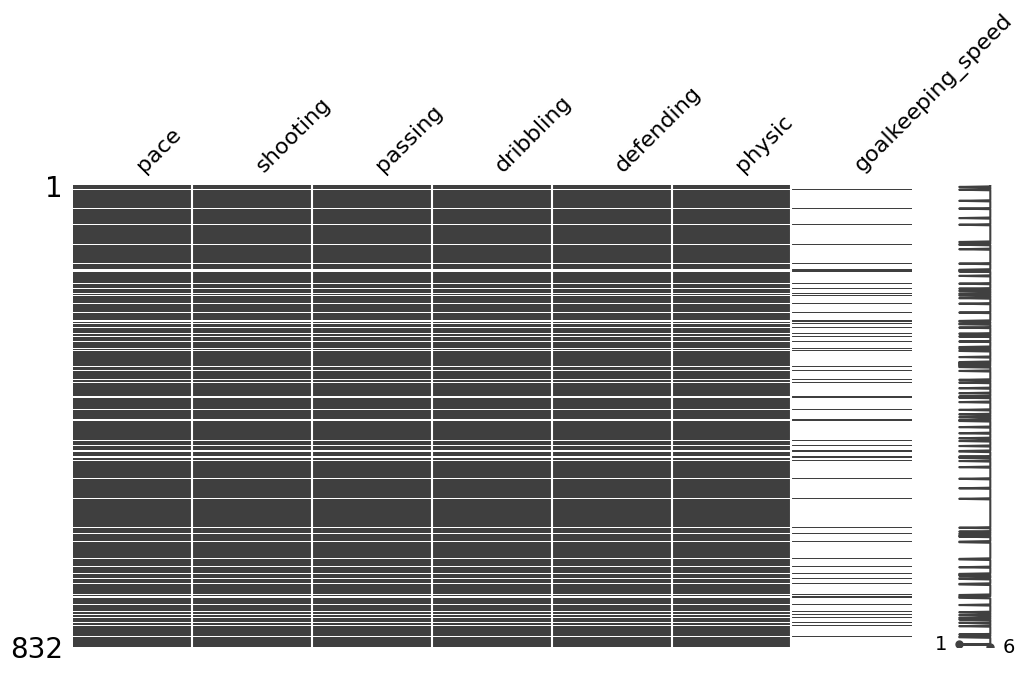

In [ ]:
import missingno as msno

missing_df = df[val_falt[val_falt > 0].index]
msno.matrix(missing_df, figsize=(12, 6))

En efecto, es posible ver que en casi todas las columnas existen valores faltantes para las mismas jugadoras, aunque en la última columna, dichas jugadoras sí presentan información.
Al ordenar de acuerdo a una de las columnas, es posible ver la siguiente relación.

<Axes: >

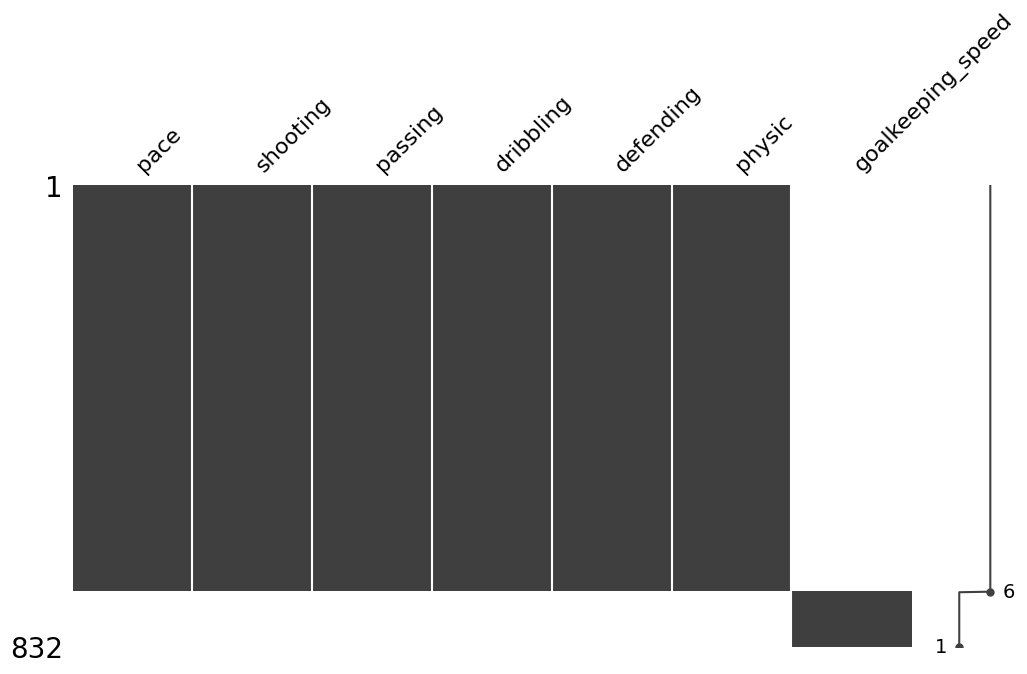

In [ ]:
msno.matrix(missing_df.sort_values(by='pace'), figsize=(12, 6))

Para terminar de comprobar la relación inversa entre las ausencias de valores, se realizó una matriz de correlaciones.

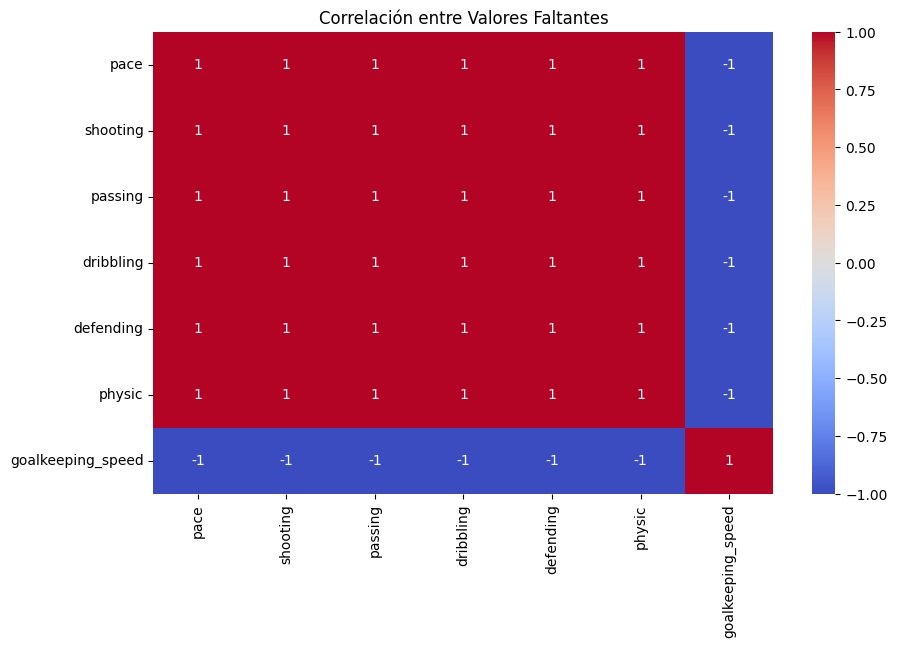

In [ ]:
# Calcular la matriz de correlación de los valores faltantes
missing_corr = missing_df.isnull().corr()

# Generar la visualización usando una matriz de calor
plt.figure(figsize=(10, 6))
sns.heatmap(missing_corr, cmap='coolwarm', annot=True)
plt.title("Correlación entre Valores Faltantes")
plt.show()

Esta relación inversa se explica debido a que las caracteriticas 'pace', 'shooting', 'passing', 'dribbling', 'defending' y 'physic' son características propias de jugadoras que recorren la cancha, mientras que 'goalkeeping_speed'es una caracteristica propia de las arqueras unicamente que las demas jugadoras no poseen. A su vez, una arquera no tiene las caracteristicas de las jugadoras que recorren el campo de juego y que se mencionaron anteriormente.

En base a esto y teniendo en cuenta que se utilizó un OneHotEncoding, se aplicó el mismo criterio para imputar los valores faltantes anteriores, es decir, reemplazar por 0 donde había "NaN".

In [ ]:
columns_with_nan = ['pace', 'shooting', 'passing', 'dribbling', 'defending',
                    'physic', 'goalkeeping_speed']

df_clean[columns_with_nan] = df_clean[columns_with_nan].fillna(0)

In [ ]:
val_falt = df_clean.isnull().sum()
val_falt[val_falt > 0]

Series([], dtype: int64)

De esta forma, se obtuvo un set de datos curado e imputado listo para ser utilizado con algoritmos de Aprendizaje No Supervisado.

In [ ]:
df_clean.to_csv('df_clean.csv', index=False)